<a href="https://colab.research.google.com/github/Gh4n5kH/mugni-data-science-2024/blob/main/Pertemuan7_Mugni_240401010355.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Langkah 1: Generate & Eksplorasi Dataset**

Shape: (300, 4)
       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22

Contoh Data:
   pengalaman  edu      kota       gaji
0    7.490802    0   Jakarta  21.953247
1   19.014286    1   Jakarta  46.721665
2   14.639879    2  Surabaya  34.952649
3   11.973170    2   Bandung  32.437143
4    3.120373    2   Jakarta  17.384265


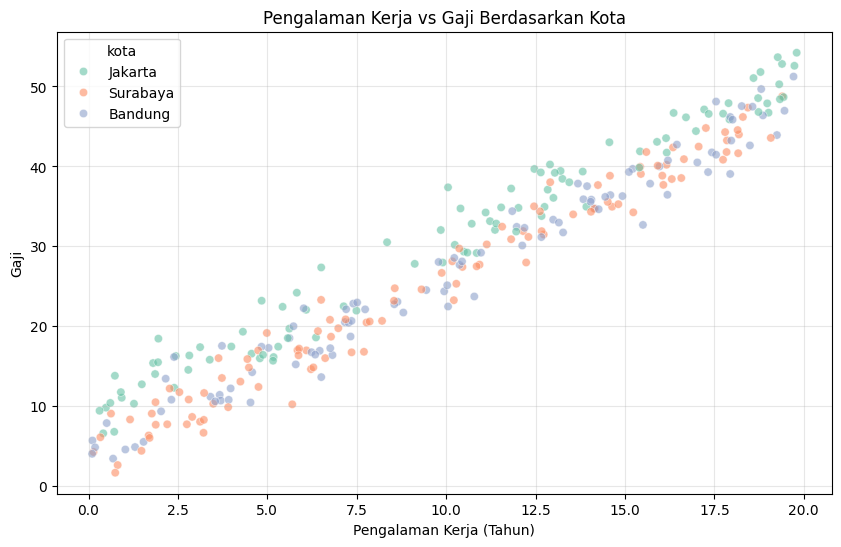

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Menentukan seed agar hasil random selalu sama setiap kali dijalankan
np.random.seed(42)

# Jumlah data yang akan dibuat
n = 300

# Membuat data pengalaman kerja antara 0 - 20 tahun
pengalaman = np.random.uniform(0, 20, n)

# Membuat data tingkat pendidikan
# 0 = SMA
# 1 = D3
# 2 = S1
edu = np.random.choice([0, 1, 2], n)

# Membuat data kota secara acak
kota = np.random.choice(
    ['Jakarta', 'Surabaya', 'Bandung'],
    n
)

# Membuat data gaji sintetis
# Rumus:
# - Gaji dasar = 3 juta
# - Tambahan 2.2 juta per tahun pengalaman
# - Tambahan 1.5 juta sesuai tingkat pendidikan
# - Bonus 4 juta jika bekerja di Jakarta
# - Ditambah noise/random agar lebih realistis
gaji = (
    3.0
    + (2.2 * pengalaman)
    + (1.5 * edu)
    + np.where(kota == 'Jakarta', 4.0, 0)
    + np.random.normal(0, 2, n)
)

# Membuat DataFrame
df = pd.DataFrame({
    'pengalaman': pengalaman,
    'edu': edu,
    'kota': kota,
    'gaji': gaji
})

# Exploratory Data Analysis

print("Shape:", df.shape) # Menampilkan jumlah baris dan kolom
print(df.describe().round(2)) # Menampilkan statistik deskriptif
print("\nContoh Data:") # Menampilkan beberapa data pertama
print(df.head())

# Visualisasi Data

plt.figure(figsize=(10, 6)) # Mengatur ukuran grafik

# Scatter plot pengalaman vs gaji
# Warna dibedakan berdasarkan kota
sns.scatterplot(
    data=df,
    x='pengalaman',
    y='gaji',
    hue='kota',
    palette='Set2',
    alpha=0.6
)

plt.title('Pengalaman Kerja vs Gaji Berdasarkan Kota') # Judul grafik
plt.xlabel('Pengalaman Kerja (Tahun)') # Label sumbu X
plt.ylabel('Gaji') # Label sumbu Y
plt.grid(True, alpha=0.3) # Menampilkan grid agar mudah dibaca
plt.show() # Menampilkan grafik

**Langkah 2: Preprocessing**

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Encoding Variabel Kategorikal

df = pd.get_dummies(
    df,
    columns=['kota'],
    drop_first=True,
    dtype=int
)

# Menampilkan nama kolom setelah encoding
print("Kolom setelah encoding:")
print(df.columns.tolist())


# Memisahkan Fitur dan Target

X = df.drop('gaji', axis=1) # X = fitur (variabel independen)
y = df['gaji'] # y = target yang akan diprediksi


# Membagi Data Training dan Testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Menampilkan jumlah data train dan test
print(
    f"Train: {X_train.shape[0]} baris, "
    f"Test: {X_test.shape[0]} baris"
)

scaler = StandardScaler() # Feature Scaling (Standardization)
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Informasi Hasil Scaling

print("Shape X_train_s:", X_train_s.shape)
print("Shape X_test_s :", X_test_s.shape)

Kolom setelah encoding:
['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']
Train: 240 baris, Test: 60 baris
Shape X_train_s: (240, 4)
Shape X_test_s : (60, 4)


**Langkah 3: Latih Model & Tampilkan Koefisien**

In [4]:
from sklearn.linear_model import LinearRegression

# Membuat dan Melatih Model
model = LinearRegression()
model.fit(X_train_s, y_train)

# Menampilkan Intercept (β₀)

print(f"β₀ (Intercept): {model.intercept_:.3f}")
print()

# Menampilkan Koefisien Setiap Fitur

coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': model.coef_.round(3)
})

# Urutkan dari pengaruh terbesar ke terkecil
coef_df = coef_df.sort_values(
    by='Koefisien',
    ascending=False
)

print(coef_df.to_string(index=False)) # Tampilkan hasil

# Interpretasi Koefisien
# Koefisien positif:
# Nilai fitur naik → prediksi gaji naik
# Koefisien negatif:
# Nilai fitur naik → prediksi gaji turun
# Semakin besar nilai absolut koefisien,
# semakin besar pengaruh fitur terhadap prediksi

β₀ (Intercept): 27.514

        Fitur  Koefisien
   pengalaman     13.042
 kota_Jakarta      1.837
          edu      1.188
kota_Surabaya     -0.292


**Langkah 4: Evaluasi Model**

In [8]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

# Prediksi
y_pred = model.predict(X_test_s)

# Metrik evaluasi
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Tampilkan hasil
print("=== Metrik Evaluasi ===")
print(f"MAE  = {mae:.3f} juta rupiah")
print(f"RMSE = {rmse:.3f} juta rupiah")
print(f"R²   = {r2:.4f} ({r2*100:.1f}% variasi dijelaskan)")
print(f"Selisih RMSE-MAE = {rmse - mae:.3f}")

=== Metrik Evaluasi ===
MAE  = 1.649 juta rupiah
RMSE = 2.123 juta rupiah
R²   = 0.9740 (97.4% variasi dijelaskan)
Selisih RMSE-MAE = 0.474


**Langkah 5: Visualisasi & Interpretasi**

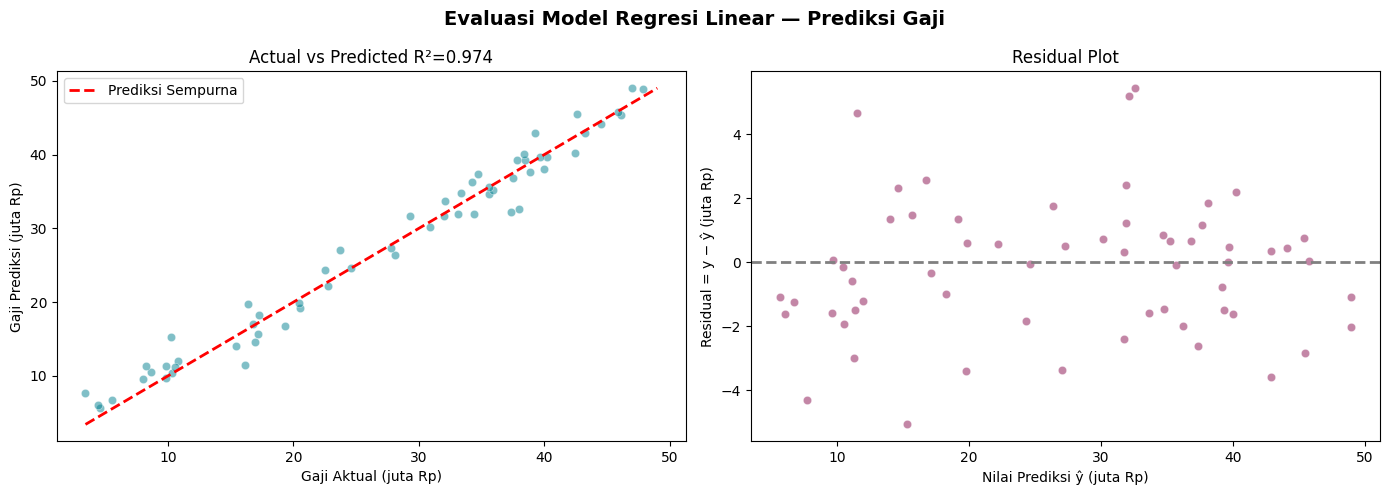

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(
    y_test, y_pred,
    alpha=0.5,
    color='#028090',
    edgecolors='white',
    lw=0.5
)

lims = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]

axes[0].plot(lims, lims, 'r--', lw=2, label='Prediksi Sempurna')
axes[0].set_xlabel('Gaji Aktual (juta Rp)')
axes[0].set_ylabel('Gaji Prediksi (juta Rp)')
axes[0].set_title(f'Actual vs Predicted R²={r2:.3f}')
axes[0].legend()

# Plot 2: Residual Plot
residuals = y_test - y_pred

axes[1].scatter(
    y_pred,
    residuals,
    alpha=0.5,
    color='#880E4F',
    edgecolors='white',
    lw=0.5
)

axes[1].axhline(0, color='gray', linestyle='--', lw=2)
axes[1].set_xlabel('Nilai Prediksi ŷ (juta Rp)')
axes[1].set_ylabel('Residual = y − ŷ (juta Rp)')
axes[1].set_title('Residual Plot')

plt.suptitle('Evaluasi Model Regresi Linear — Prediksi Gaji',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('evaluasi_regresi.png', dpi=150, bbox_inches='tight')
plt.show()

# Cara membaca Residual Plot:
# ✅ Baik: titik tersebar acak di sekitar 0
# ❌ Buruk: ada pola (kurva / corong)

* Plot 1

Membandingkan gaji aktual (sumbu X) dengan gaji prediksi (sumbu Y).
Garis putus-putus merah merepresentasikan kondisi prediksi sempurna, yaitu ketika nilai prediksi sama persis dengan nilai aktual. Sebagian besar titik yang berada dekat dengan garis tersebut menunjukkan bahwa hasil prediksi model sudah sangat mendekati nilai sebenarnya, dengan nilai koefisien determinasi R² = 0.974 yang menandakan performa model sangat baik.

Secara keseluruhan, model regresi ini sudah layak digunakan untuk keperluan prediksi.

* Plot 2

Menampilkan residual, yaitu selisih antara nilai aktual dan nilai prediksi (y − ŷ), dengan garis horizontal pada y = 0 sebagai acuan kondisi error nol. Sebaran titik yang terlihat acak di sekitar garis nol menunjukkan bahwa error model tidak memiliki pola tertentu. Tidak terlihat adanya pola melengkung (non-linearitas), tidak ada bentuk corong (heteroskedastisitas), serta tidak ditemukan outlier ekstrem yang jauh dari kelompok data utama.

Hal ini mengindikasikan bahwa asumsi dasar regresi linear terpenuhi dengan baik, sehingga model dapat dianggap valid secara statistik.